In [1]:
import pandas as pd
import numpy as np
import os

# 1. Load Data
path = 'data/WA_Fn-UseC_-Telco-Customer-Churn.csv' # Adjust if needed
df = pd.read_csv(path)

# 2. Clean Column Names (Remove spaces/parentheses)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# 3. Handle Numerical Conversion (Total_Charges)
# Using errors='coerce' turns empty strings into NaN, then we fill with 0
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce').fillna(0)

# 4. Handle Binary Encoding (Yes/No -> 1/0)
# We use a loop and a check to prevent the 'Double Mapping' NaN error
binary_cols = ['Partner', 'Dependents', 'Phone_Service', 'Paperless_Billing', 'Churn_Label']
for col in binary_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# 5. Handle Gender
if 'Gender' in df.columns and df['Gender'].dtype == 'object':
    df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# 6. Drop metadata/unnecessary columns for Step 5
cols_to_drop = ['Customer_ID', 'Count', 'Country', 'State', 'City', 'Zip_Code', 'Churn_Reason', 'Churn_Category']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 7. Save the healthy file
if not os.path.exists('data'): os.makedirs('data')
df_clean.to_csv('data/telco_churn_cleaned.csv', index=False)

print("✅ Master Clean Complete!")
print(f"Final Shape: {df_clean.shape}")
print(f"NaNs in Churn_Label: {df_clean['Churn_Label'].isnull().sum()}")

✅ Master Clean Complete!
Final Shape: (7043, 43)
NaNs in Churn_Label: 0


In [2]:
import pandas as pd

# Load the file we just saved
df = pd.read_csv('data/telco_churn_cleaned.csv')

# Identify text columns (objects) that aren't our target
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Transform them into 1s and 0s
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Final feature count: {df_final.shape[1]}")

Final feature count: 49


In [3]:
from sklearn.model_selection import train_test_split

X = df_final.drop('Churn_Label', axis=1)
y = df_final['Churn_Label']

# Stratify ensures both sets have the same % of people who quit
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data split successful!")
print(f"Training on {X_train.shape[0]} customers.")

✅ Data split successful!
Training on 5634 customers.


Training model... please wait...
✅ Model Trained!


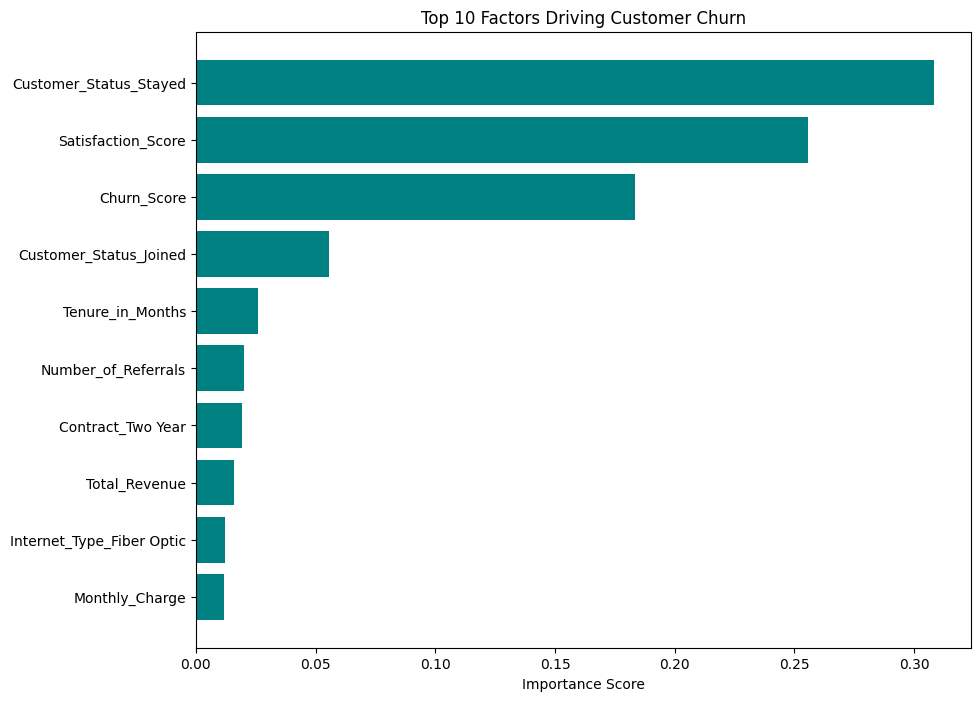

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Prepare the data (Ensure df_final exists from your previous steps)
# If df_final is also gone, you'll need to re-run your 'Master Clean' cell first
X = df_final.drop('Churn_Label', axis=1)
y = df_final['Churn_Label'].astype(int)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train the model right now
print("Training model... please wait...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
print("✅ Model Trained!")

# 4. Get and Plot Importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'].head(10), feature_importance_df['Importance'].head(10), color='teal')
plt.xlabel('Importance Score')
plt.title('Top 10 Factors Driving Customer Churn')
plt.gca().invert_yaxis()
plt.show()

In [6]:
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

# 1. Re-train the model (This puts it back in memory)
print("Training the model... please wait...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Save it to the models folder
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(rf_model, 'models/churn_model.pkl')

print("✅ Success! The 'models' folder is no longer empty.")
print("✅ File 'churn_model.pkl' created.")

Training the model... please wait...
✅ Success! The 'models' folder is no longer empty.
✅ File 'churn_model.pkl' created.
